# Popularity Baseline and Collaborative Filtering for Books

This notebook builds the first two recommendation models for the Goodbooks side of my project. It mirrors the structure of my Coursera prototype notebook, applying the same two approaches to the filtered educational books dataset:

1. **Popularity baseline** — non-personalized, ranks books by a combined score of average rating and rating count.
2. **Collaborative filtering (CF)** — personalized, uses Singular Value Decomposition (SVD) from the Surprise library to predict each user's rating for books they have not read.

Both models are evaluated on the same held-out test set using RMSE and MAE. Running the same comparison on a second dataset tests whether the improvement from personalization holds beyond the Coursera data.

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt

# Collaborative filtering library
from surprise import SVD, Dataset, Reader, accuracy
from surprise.model_selection import train_test_split

# Saving the trained model for later stages
import pickle

# Warnings
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded")

Libraries loaded


In [2]:
# Load the filtered Goodbooks datasets
books = pd.read_csv('books_filtered.csv')
ratings = pd.read_csv('ratings_filtered.csv')

print(f"Number of books: {len(books)}")
print(f"Number of ratings: {len(ratings):,}")
print(f"\nBook columns used: ['book_id', 'title', 'authors']")
print(f"Rating columns: {list(ratings.columns)}")

print(f"\nFirst 5 books:")
print(books[['title', 'authors']].head().to_string(index=False))

Number of books: 593
Number of ratings: 217,744

Book columns used: ['book_id', 'title', 'authors']
Rating columns: ['user_id', 'book_id', 'rating']

First 5 books:
                                                                                    title                             authors
Freakonomics: A Rogue Economist Explores the Hidden Side of Everything (Freakonomics, #1) Steven D. Levitt, Stephen J. Dubner
                           The Tipping Point: How Little Things Can Make a Big Difference                    Malcolm Gladwell
                                                           Outliers: The Story of Success                    Malcolm Gladwell
                                                     The Immortal Life of Henrietta Lacks                      Rebecca Skloot
                                            Blink: The Power of Thinking Without Thinking                    Malcolm Gladwell


---
## Checking the catalogue against the target users

My curation notebook selected books using community tags rather than titles, in two stages: an educational tag threshold plus a fiction filter, then an off-scope exclusion filter for religion, poetry, memoir, and biography. Here I check what the retained books are actually tagged as, to see how well the final catalogue matches the learning scope described in my Design chapter.

In [3]:
# Load the tag files to inspect what the retained books are tagged as
tags = pd.read_csv('tags.csv')
book_tags = pd.read_csv('book_tags.csv')

# Keep only tags applied to the retained books
retained_ids = set(books['goodreads_book_id'])
retained_tags = book_tags[book_tags['goodreads_book_id'].isin(retained_ids)]

# Sum tag usage across the retained catalogue and attach tag names
tag_profile = (
    retained_tags.groupby('tag_id')['count'].sum()
    .reset_index()
    .merge(tags, on='tag_id')
    .nlargest(25, 'count')[['tag_name', 'count']]
)

print("Top 25 tags across the 593 retained books:")
print(tag_profile.to_string(index=False))

Top 25 tags across the 593 retained books:
         tag_name    count
          to-read 10606570
currently-reading   747576
      non-fiction   412866
       nonfiction   179277
          science   113377
        favorites    96238
          history    90082
       philosophy    88515
       psychology    71949
         business    70333
            owned    43721
        self-help    42891
        biography    31451
      books-i-own    30290
         classics    29968
         politics    27905
        audiobook    23764
        book-club    23163
           memoir    22474
           to-buy    22269
        economics    21776
           kindle    19950
          library    19915
       audiobooks    18604
 self-improvement    17077


> The tag profile confirms the two-stage filter worked. Non-fiction dominates, followed by science, history, philosophy, psychology, business, and economics — all within the educational scope defined in my Design chapter, and no fiction genres appear in the top 25.

> The filter is not perfect. A small number of memoir and general-interest titles survive because their educational tag counts still exceed their off-scope counts, which is an inherent limitation of filtering on crowd-sourced tags rather than curated subject metadata. A second limitation is that Goodbooks-10K contains the most widely-rated books on Goodreads, which means popular science and business writing rather than technical manuals. The catalogue therefore supports conceptual and foundational reading, which fits the personas in my Design chapter, but does not contain deep technical textbooks.

---
## Exploring the ratings dataset

A check of the dataset size, sparsity, and rating distribution before modelling, matching the checks I ran on the Coursera reviews.

In [4]:
# Explore the ratings dataset
n_users = ratings['user_id'].nunique()
n_books_rated = ratings['book_id'].nunique()
sparsity = 100 * (1 - len(ratings) / (n_users * n_books_rated))

print(f"Unique users: {n_users:,}")
print(f"Books with at least one rating: {n_books_rated:,}")
print(f"Sparsity: {sparsity:.2f}%")

print(f"\nRating distribution:")
print(ratings['rating'].value_counts().sort_index())

print(f"\nMissing values per column:")
print(ratings.isnull().sum())

Unique users: 34,974
Books with at least one rating: 593
Sparsity: 98.95%

Rating distribution:
rating
1     4415
2    12440
3    49888
4    81694
5    69307
Name: count, dtype: int64

Missing values per column:
user_id    0
book_id    0
rating     0
dtype: int64


> The books dataset is far less skewed than the Coursera reviews. Only 31.8% of book ratings are 5 stars, compared with 76.8% of course reviews, and the ratings spread across 3, 4, and 5 stars rather than concentrating at the top. Sparsity is comparable at 98.95%.

> The wider spread makes rating prediction a harder task on this dataset, so I expect higher RMSE and MAE values here than the Coursera models produced. This means the two datasets' error values are not directly comparable — what matters in each case is how far the personalized model improves on its own baseline.

---
## Visualizing the distributions

Three charts: rating distribution, ratings per book, and ratings per user.

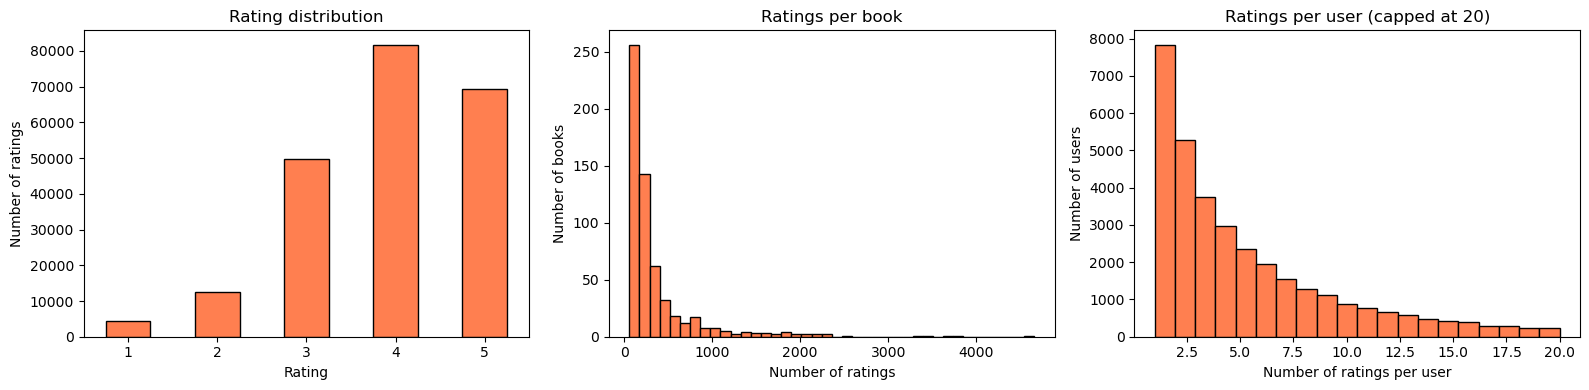

In [5]:
# Visualize the data distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Rating distribution
ratings['rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='coral', edgecolor='black'
)
axes[0].set_title('Rating distribution')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Number of ratings')
axes[0].set_xticklabels([1, 2, 3, 4, 5], rotation=0)

# 2. Ratings per book (how popular is each book)
ratings.groupby('book_id').size().plot(
    kind='hist', bins=40, ax=axes[1], color='coral', edgecolor='black'
)
axes[1].set_title('Ratings per book')
axes[1].set_xlabel('Number of ratings')
axes[1].set_ylabel('Number of books')

# 3. Ratings per user (capped at 20 because most users rate only a few books)
ratings_per_user = ratings.groupby('user_id').size()
ratings_per_user[ratings_per_user <= 20].plot(
    kind='hist', bins=20, ax=axes[2], color='coral', edgecolor='black'
)
axes[2].set_title('Ratings per user (capped at 20)')
axes[2].set_xlabel('Number of ratings per user')
axes[2].set_ylabel('Number of users')

plt.tight_layout()
plt.show()

> The three charts confirm the patterns behind the sparsity figure. Ratings peak at 4 stars rather than 5, giving a more balanced distribution than the Coursera reviews. Ratings per book follow a long tail: most books have fewer than 500 ratings while a small number exceed 4,000, so a popularity-based ranking will be dominated by a handful of titles. Ratings per user decay steeply, with the largest group of users having rated only one or two books. This concentration of users with very short histories is the cold-start pattern that motivates the content-based model built later in the project.

---
## Feature engineering: popularity statistics

For each book I calculate the average rating and rating count from my filtered ratings table, then combine them into a single popularity score. I compute these from the filtered ratings rather than using the `average_rating` column supplied with the dataset, so that the popularity baseline and the collaborative filtering model are built from exactly the same data.

In [6]:
# Calculate average rating and rating count per book
book_stats = ratings.groupby('book_id').agg(
    avg_rating=('rating', 'mean'),
    n_ratings=('rating', 'count')
).reset_index()

# Merge these stats into the books table
books = books.merge(book_stats, on='book_id', how='left')

# Drop books with no ratings (can't recommend what nobody rated)
books = books.dropna(subset=['n_ratings']).copy()

# Popularity score = average rating boosted by log of rating count
books['popularity_score'] = books['avg_rating'] * np.log1p(books['n_ratings'])

print(f"Books with at least one rating: {len(books)}")
print(f"\nTop 5 most popular books:")
print(books.nlargest(5, 'popularity_score')[
    ['title', 'authors', 'avg_rating', 'n_ratings', 'popularity_score']
].to_string(index=False))

Books with at least one rating: 593

Top 5 most popular books:
                                                                                    title                             authors  avg_rating  n_ratings  popularity_score
                                                     The Immortal Life of Henrietta Lacks                      Rebecca Skloot    4.011914       3777         33.045937
Freakonomics: A Rogue Economist Explores the Hidden Side of Everything (Freakonomics, #1) Steven D. Levitt, Stephen J. Dubner    3.888364       4658         32.843286
                                                           Outliers: The Story of Success                    Malcolm Gladwell    4.024504       3428         32.759560
                                                                         The Last Lecture        Randy Pausch, Jeffrey Zaslow    4.151125       2488         32.460291
                                                                 Man's Search for Meaning             

---
## Popularity baseline model

A simple function that returns the top-K most popular books. The same recommendation is returned for every user, so this acts as the benchmark for testing whether personalization improves on giving everyone the same popular items.

In [7]:
# Popularity baseline: same top-K recommendations for every user
def recommend_popular_books(top_k=10):
    return books.nlargest(top_k, 'popularity_score')[
        ['title', 'authors', 'avg_rating', 'n_ratings']
    ]

print("Top 10 books by popularity baseline:")
print(recommend_popular_books(10).to_string(index=False))

Top 10 books by popularity baseline:
                                                                                    title                             authors  avg_rating  n_ratings
                                                     The Immortal Life of Henrietta Lacks                      Rebecca Skloot    4.011914       3777
Freakonomics: A Rogue Economist Explores the Hidden Side of Everything (Freakonomics, #1) Steven D. Levitt, Stephen J. Dubner    3.888364       4658
                                                           Outliers: The Story of Success                    Malcolm Gladwell    4.024504       3428
                                                                         The Last Lecture        Randy Pausch, Jeffrey Zaslow    4.151125       2488
                                                                 Man's Search for Meaning                    Viktor E. Frankl    4.314614       1656
                                                     A Short History 

## Preparing the data for the Surprise library

The ratings are converted into the (user, item, rating) format the Surprise library expects.

In [8]:
# Convert the ratings into the format Surprise expects
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(ratings[['user_id', 'book_id', 'rating']], reader)

print("Data loaded into Surprise format")

Data loaded into Surprise format


---
## Training the collaborative filtering model

The data is split 80/20 with a fixed random seed so results are reproducible, then an SVD model is trained on the training set using the same settings as my Coursera model: 50 latent factors and 20 epochs.

In [9]:
# Split into 80% training and 20% testing
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

# Train the SVD model: 50 latent factors, 20 training rounds (epochs)
model = SVD(n_factors=50, n_epochs=20, random_state=42)
model.fit(trainset)

print(f"Training set: {trainset.n_ratings:,} ratings")
print(f"Test set: {len(testset):,} ratings")
print("Model trained")

Training set: 174,195 ratings
Test set: 43,549 ratings
Model trained


---
## Evaluating the CF model on the test set

The trained model predicts ratings for the held-out test set, and the error is measured with RMSE and MAE.

In [10]:
# Predict ratings for the held-out test set
predictions = model.test(testset)

# Calculate Root Mean Square Error and Mean Absolute Error (lower is better)
rmse = accuracy.rmse(predictions)
mae = accuracy.mae(predictions)

RMSE: 0.8811
MAE:  0.6981


> The CF model achieves RMSE 0.8811 and MAE 0.6981 on the held-out test set. These values are substantially higher than the 0.4806 and 0.3115 my Coursera model produced, which is consistent with the rating distributions: Coursera reviews concentrate 76.8% of ratings at 5 stars, so predicting "close to 5" is nearly always correct, whereas book ratings spread across 3, 4, and 5 and give the model far less of an easy target. The comparison against each dataset's own popularity baseline is therefore the meaningful test, not the absolute error values.

---
## Personalized recommendations for a sample user

I pick the most active user in the dataset, predict their rating for every book they have not yet rated, then return the ten with the highest predictions. Comparing this list against the popularity baseline shows whether the model is genuinely personalizing.

In [11]:
# Pick the most active user
sample_user = ratings['user_id'].value_counts().index[0]
rated_by_user = set(ratings[ratings['user_id'] == sample_user]['book_id'].values)

# Predict ratings for all books this user has NOT rated
all_book_ids = books['book_id'].unique()
unrated = [b for b in all_book_ids if b not in rated_by_user]

cf_predictions = []
for book_id in unrated:
    pred = model.predict(sample_user, book_id)
    cf_predictions.append((book_id, pred.est))

# Sort by predicted rating and take the top 10
cf_predictions.sort(key=lambda x: x[1], reverse=True)
top_10 = cf_predictions[:10]

# Look up the book titles
top_10_df = pd.DataFrame(top_10, columns=['book_id', 'predicted_rating'])
top_10_df = top_10_df.merge(books[['book_id', 'title', 'authors']], on='book_id')
top_10_df['predicted_rating'] = top_10_df['predicted_rating'].round(3)

print(f"Sample user: {sample_user}")
print(f"Books already rated: {len(rated_by_user)}")
print(f"\nTop 10 personalized recommendations from the CF model:\n")
print(top_10_df[['title', 'authors', 'predicted_rating']].to_string(index=False))

Sample user: 38237
Books already rated: 97

Top 10 personalized recommendations from the CF model:

                                                                                               title                                                                                       authors  predicted_rating
                                                                         Humans of New York: Stories                                                                               Brandon Stanton             4.521
                                                                                  Humans of New York                                                                               Brandon Stanton             4.379
                                                    Evicted: Poverty and Profit in the American City                                                                               Matthew Desmond             4.340
                                          The Be

> The personalized list differs completely from the popularity baseline, confirming that the model is responding to this user's individual history rather than returning globally popular titles. It also illustrates a known property of collaborative filtering: because the model learns only from co-rating patterns and never reads the content of an item, its recommendations reflect what similar users read rather than what a given topic is about. This is the limitation that the content-based and cross-medium models address in the next stages of the project, where recommendations are driven by the meaning of the item rather than by rating patterns alone.

---
## Comparing both models on the same test set

Both models are scored on exactly the same test cases. The popularity baseline predicts each book's average rating from the training data, while CF predicts a personalized rating for each user-book pair. Both sets of predictions are compared against the real ratings.

In [12]:
# Popularity baseline: predict each book's average rating
book_avg = books.set_index('book_id')['avg_rating'].to_dict()
global_avg = ratings['rating'].mean()

def popularity_predict(book_id):
    return book_avg.get(book_id, global_avg)

# Generate popularity predictions for the test set
pop_actual_pairs = [(p.r_ui, popularity_predict(p.iid)) for p in predictions]

# Calculate RMSE and MAE for the popularity baseline
pop_rmse = np.sqrt(np.mean([(t - p)**2 for t, p in pop_actual_pairs]))
pop_mae = np.mean([abs(t - p) for t, p in pop_actual_pairs])

# Build a comparison table
comparison = pd.DataFrame({
    'Model': ['Popularity Baseline', 'Collaborative Filtering (SVD)'],
    'RMSE': [pop_rmse, rmse],
    'MAE': [pop_mae, mae]
})
print(comparison.to_string(index=False))

rmse_improvement = (pop_rmse - rmse) / pop_rmse * 100
mae_improvement = (pop_mae - mae) / pop_mae * 100
print(f"\nCF improvement over popularity baseline:")
print(f"  RMSE: {rmse_improvement:.1f}% lower")
print(f"  MAE:  {mae_improvement:.1f}% lower")

                        Model     RMSE      MAE
          Popularity Baseline 0.949566 0.750915
Collaborative Filtering (SVD) 0.881067 0.698148

CF improvement over popularity baseline:
  RMSE: 7.2% lower
  MAE:  7.0% lower


>The CF model reduces RMSE by 7.2% and MAE by 7.0% against the popularity baseline on the same held-out test set. This is a smaller margin than the 31.2% RMSE improvement the CF model achieved on the Coursera data, which is consistent with the two rating distributions: the heavy 5-star skew in the Coursera reviews gives the popularity baseline a much weaker starting point, whereas the more evenly spread book ratings make the average rating a stronger predictor and therefore a harder baseline to beat.

>The key finding is that personalization improves on a non-personalized baseline in both domains, which supports extending the same modelling approach across both mediums in the hybrid model.

---
## Visualizing the comparison

A bar chart of RMSE and MAE for both models, matching the format used in my Coursera prototype so the two datasets can be compared side by side in the report.

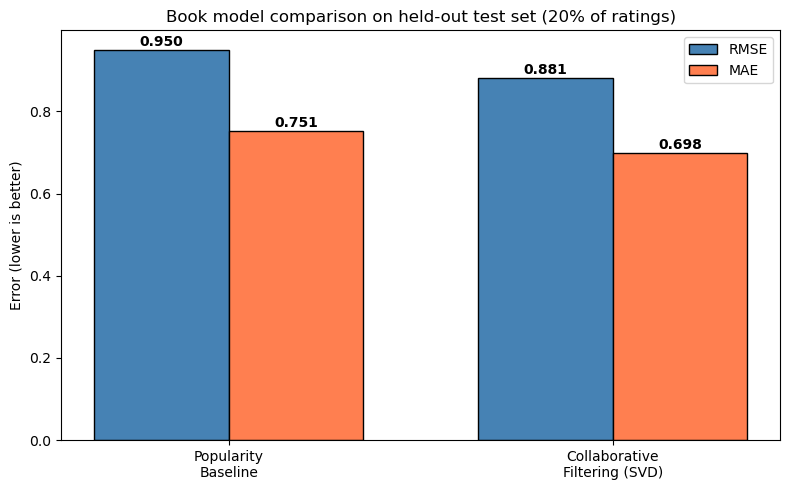

In [13]:
# Bar chart comparing the two models on RMSE and MAE
fig, ax = plt.subplots(figsize=(8, 5))

models = ['Popularity\nBaseline', 'Collaborative\nFiltering (SVD)']
rmse_values = [pop_rmse, rmse]
mae_values = [pop_mae, mae]

x = np.arange(len(models))
width = 0.35

ax.bar(x - width/2, rmse_values, width, label='RMSE', color='steelblue', edgecolor='black')
ax.bar(x + width/2, mae_values, width, label='MAE', color='coral', edgecolor='black')

ax.set_ylabel('Error (lower is better)')
ax.set_title('Book model comparison on held-out test set (20% of ratings)')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

for i, v in enumerate(rmse_values):
    ax.text(i - width/2, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')
for i, v in enumerate(mae_values):
    ax.text(i + width/2, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

---
## Saving the model artifacts

Save the trained CF model and the books table with its popularity statistics, so that later stages of the project can load them without retraining.

In [14]:
# Save the trained CF model
with open('cf_model_books.pkl', 'wb') as f:
    pickle.dump(model, f)

# Save the books table with popularity statistics
books.to_csv('books_with_popularity.csv', index=False)

print("Saved: cf_model_books.pkl")
print("Saved: books_with_popularity.csv")

Saved: cf_model_books.pkl
Saved: books_with_popularity.csv
